### Monte Carlo Simulation to find Euler Mascheroni Constant $\gamma$

The harmonic mean $M_n = \frac{n}{H_n}$ (where $H_n$ is the harmonic number $\sum_{k = 1}^{n} \frac{1}{k}$) is close to $\ln{n}$ + $\gamma$ ($\approx 0.577$ Euler-Mascheroni Constant) for $n \rightarrow \infty$.

$$M_n \approx \frac{n}{\ln{n} + \gamma} \Rightarrow M_n (\ln{n} + \gamma) - n \approx 0$$

We can find $\gamma$ algebrically

$$\gamma \approx \frac{n - M_n \ln n}{M_n} = \frac{n}{M_n} - \ln{n} = H_n - \ln n$$

The number of primes less or equals to $n$ $\geq 0$ is $P(n)$ or $\pi(n)$. $$ \\ $$ 
$\pi(n \rightarrow \infty)$ is close to $\frac{n}{\ln n}$. $$ \\ $$ 

For a large denominator $\gamma$ effect is insignificant and there is no difference between $\pi(n) = \frac{n}{\ln n}$ and $M_n = \frac{n}{\ln(n) + \gamma}$

The problem here is the validity of the asymptotes. They becoming valid only for really huge numbers. For example, we'll found that $10^{23}$ is really small computing $\delta_n$. $ \\ $ $\delta_n$ is defined as:

$$\delta_n = \frac{n}{\pi(n)} - \ln n \Rightarrow \pi(n) (\ln n + \delta_n) = n$$

$$\gamma = \frac{n}{M_n} - \ln n \Rightarrow M_n (\ln n + \gamma) = n$$

In [20]:
from matplotlib import pyplot as plt
from math import log
from mpmath import mp, li # from euler constant
from IPython.display import display, Markdown
import numba as nb
import numpy as np
from sys import stdout

mp.dps = 16

In [21]:
def md_print(msg: str) -> None: # markdown print
    display(Markdown(msg))

In [22]:
N = 1_000_000_000 # upper limit

In [23]:
@nb.njit
def compute_H_n(n):
    H_n = 0.0
    for k in range(1, n+1):
        H_n += 1 / k
    return H_n

In [24]:
print(f"{N=:_}")

H_n = compute_H_n(N)
M_n = N / H_n

gamma = H_n - log(N)
print(f"Estimated Euler-Mascheroni constant:\t{gamma}")
print(f"Real Euler-Mascheroni constant:\t\t{mp.euler}")
relative_error = abs(gamma - mp.euler) / mp.euler
print(f"Relative error: \t\t\t{relative_error}")

N=1_000_000_000
Estimated Euler-Mascheroni constant:	0.5772156654021394
Real Euler-Mascheroni constant:		0.5772156649015329
Relative error: 			8.672781884634691e-10


In [25]:
@nb.njit
def compute_primes_less_than_n(n):
    primes = []
    sieve = np.ones(n, dtype=np.bool_)
    sieve[0:2] = False
    for p in range(2, n):
        if sieve[p]:
            primes.append(p)
            for multiple in range(p*p, n, p):
                sieve[multiple] = False
    primes = np.array(primes, dtype=np.int64)
    return primes

In [26]:
@nb.njit
def compute_primes_less_than_n_only_length(n):
    n_primes = 0
    sieve = np.ones(n, dtype=np.bool_)
    sieve[0:2] = False
    for p in range(2, n):
        if sieve[p]:
            n_primes += 1
            for multiple in range(p*p, n, p):
                sieve[multiple] = False
    return n_primes

In [27]:
@nb.njit
def compute_P_n_array(n, primes):
    P_n_array = np.zeros(n, dtype=np.uint64)
    prime_index = 0
    current_prime = primes[prime_index]
    for i in range(2, n+1):
        if i == current_prime:
            prime_index += 1
            if prime_index < len(primes):
                current_prime = primes[prime_index]
        P_n_array[i-1] = prime_index
    return P_n_array # P[n] corresponds to P(n+1)

Calculating primes for n=1024... Done! ✅


Estimated difference $\delta = \frac{n}{\pi(n)} - \ln n \approx -0.9779834335064299$

Calculating primes for n=2048... Done! ✅


Estimated difference $\delta = \frac{n}{\pi(n)} - \ln n \approx -0.9967872709490422$

Calculating primes for n=4096... Done! ✅


...

Estimated difference $\delta = \frac{n}{\pi(n)} - \ln n \approx -1.0732639946319242$

Calculating primes for n=16777216... Done! ✅


Estimated difference $\delta = \frac{n}{\pi(n)} - \ln n \approx -1.0703895658904354$

Calculating primes for n=33554432... Done! ✅


Estimated difference $\delta = \frac{n}{\pi(n)} - \ln n \approx -1.069237320916244$

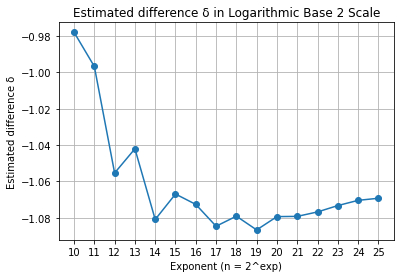

In [28]:
MAX_EXP = 25

deltas = [0.0] * (MAX_EXP - 10 + 1)

for exp in range(10, MAX_EXP + 1):
    n = 2 ** exp
    stdout.write(f"Calculating primes for {n=}...")
    stdout.flush()
    N_PRIMES = compute_primes_less_than_n_only_length(n)
    stdout.write(" Done! ✅\n")
    stdout.flush()

    delta = n / N_PRIMES - np.log(n)
    deltas[exp - 10] = delta
    md_print(r"Estimated difference $\delta = \frac{{n}}{{\pi(n)}} - \ln n \approx {}$".format(delta))

plt.plot(range(10, MAX_EXP + 1), deltas, marker='o')
plt.xticks(range(10, MAX_EXP + 1))
plt.xlabel("Exponent (n = 2^exp)")
plt.ylabel("Estimated difference δ")
plt.grid()
plt.title("Estimated difference δ in Logarithmic Base 2 Scale")
plt.show()

In _C++_ the max $P(n)$ I can estimate in a reasonable time is $P(2^{30}) = 54.400.028$

P.S. I used this script https://github.com/DanieleDiSpirito/cpp_programs/blob/main/compute_primes_less_than_N.cpp

In [29]:
n = 2**30
N_PRIMES = 54400028
most_accurate_delta_value = n / N_PRIMES - np.log(n)
md_print(r"Most accurate difference $\delta$ at $n = 2^{{30}} = {}$ $\\$ $\delta \approx {}$".format(n, most_accurate_delta_value))

Most accurate difference $\delta$ at $n = 2^{30} = 1073741824$ $\\$ $\delta \approx -1.0565243995363822$

Delta $\delta$ appears to be absolutely decreasing and will theoretically tend to $0$.

$$\lim_{n \rightarrow \infty} \delta_n = \lim_{n \rightarrow \infty} \frac{n}{\pi(n)} - \ln n = 0$$

From Wikipedia https://en.wikipedia.org/wiki/Prime_number_theorem we know that $P(n = 10^{23}) = 1.925.320.391.606.818.000.000$

In [30]:
n = 1e23
N_PRIMES = 1_925_320_391_606_818_000_000
most_accurate_delta_value = n / N_PRIMES - np.log(1e23)
md_print(r"Most accurate difference $\delta$ at $n = 10^{{23}} $ $\\$ $\delta \approx {}$".format(most_accurate_delta_value))

Most accurate difference $\delta$ at $n = 10^{23} $ $\\$ $\delta \approx -1.0200498402456972$

N=100_000_000
Calculating primes...

 Done! ✅
Computing P(n)... Done! ✅
RESCALE_FACTOR=1_000


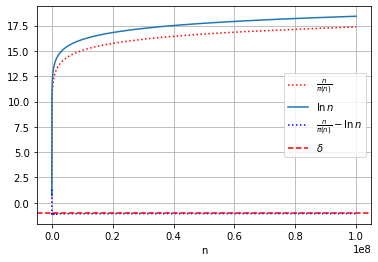

Difference between $\frac{n}{\pi(n)}$ and $\ln n$ at various n ($\delta_n$)

num=00001000: -1.0639606015
num=00010000: -1.0410714170
num=00100000: -1.0869245205
num=01000000: -1.0772326589
num=10000000: -1.0711331869
num=99999999: -1.0639606015


In [31]:
N = 100_000_000
print(f"{N=:_}")
stdout.write("Calculating primes...")
stdout.flush()
primes = compute_primes_less_than_n(N)
stdout.write(" Done! ✅\n")
stdout.flush()

stdout.write("Computing P(n)...")
stdout.flush()
p_n = compute_P_n_array(N, primes)[1:]
stdout.write(" Done! ✅\n")
stdout.flush()

MAX_N_PLOT = 100_000
RESCALE_FACTOR = N // MAX_N_PLOT if N > MAX_N_PLOT else 1

n = np.arange(2, N + 1)[::RESCALE_FACTOR]

delta = most_accurate_delta_value

p_n_rescaled = p_n[::RESCALE_FACTOR]

n_div_p_n = n / p_n_rescaled
log_n = np.log(n)
delta_array = n_div_p_n - log_n

print(f"{RESCALE_FACTOR=:_}")
plt.plot(n, n_div_p_n, linestyle='dotted', color='red')
plt.plot(n, log_n, linestyle='solid')
plt.plot(n, delta_array, linestyle='dotted', color='blue')
plt.axhline(y=delta, color='red', linestyle='--')
plt.xlabel("n")
plt.grid()
plt.legend(["$\\frac{n}{\pi(n)}$", "$\ln n$", "$\\frac{n}{\pi(n)} - \ln n$", "$\delta$"])
plt.show()

md_print(r"Difference between $\frac{n}{\pi(n)}$ and $\ln n$ at various n ($\delta_n$)")

for i in range(log(RESCALE_FACTOR, 10).__ceil__(), n_digits := log(N, 10).__ceil__()):
    idx = (10 ** i) // RESCALE_FACTOR
    diff = n_div_p_n[idx-2] - log_n[idx-2]
    num = idx * RESCALE_FACTOR
    print(f"num={str(num).zfill(n_digits)}: {diff:.10f}")

diff = n_div_p_n[-1] - log_n[-1]
print(f"num={N-1}: {diff:.10f}")

In [32]:
@nb.njit
def compute_H_n_array(n):
    H_n_array = np.zeros(n, dtype=np.float64)
    H_n = 0.0
    for k in range(1, n+1):
        H_n += 1 / k
        H_n_array[k-1] = H_n
    return H_n_array # H[n] corresponds to H_(n+1)

N=100_000_000
RESCALE_FACTOR=1_000


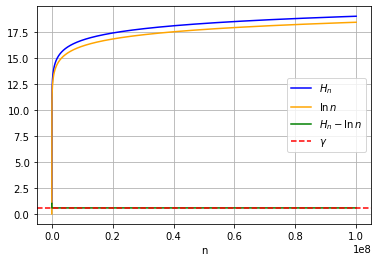

In [33]:
print(f"{N=:_}")

n = np.arange(1, N + 1)

h = compute_H_n_array(N)
log_n = np.log(n)
gamma_n = h - log_n

MAX_N_PLOT = 100_000
RESCALE_FACTOR = N // MAX_N_PLOT if N > MAX_N_PLOT else 1

print(f"{RESCALE_FACTOR=:_}")
plt.plot(n[::RESCALE_FACTOR], h[::RESCALE_FACTOR], color='blue')
plt.plot(n[::RESCALE_FACTOR], log_n[::RESCALE_FACTOR], color='orange')
plt.plot(n[::RESCALE_FACTOR], gamma_n[::RESCALE_FACTOR], color='green')
plt.axhline(y=mp.euler, color='red', linestyle='--')
plt.xlabel("n")
plt.grid()
plt.legend(["$H_n$", "$\ln n$", "$H_n - \ln n$", r"$\gamma$"])
plt.show()

#### Offset Logarithmic integral function $\mathrm{Li}(n)$

$$\pi(x) \sim \operatorname{Li}(x) = \int_{2}^{x} \frac{1}{\log t} dt \approx \frac{n}{\log n} \sum_{k=0}^{+\infty} \frac{k!}{(\log n)^k}$$

This is a more accurate approximation.

$\pi(x) = \frac{x}{\log x}$ is valid only when $n$ is large enough so that

$$\sum_{k=1}^{+\infty} \frac{k!}{(\log n)^k} \approx 0$$

Calculating primes... Done! ✅
Computing P(n)... Done! ✅
Computing Li(n)... Done! ✅
RESCALE_FACTOR=1_000


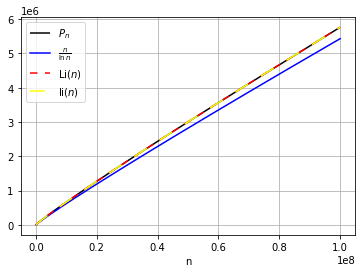

Comparison of $P(n)$ with $\frac{n}{\ln n}$, $\mathrm{Li}(n)$ and $\mathrm{li}(n)$

$P(n) = 5761403 \\ \frac{n}{\ln n} = 5428629.786704598 \\ \mathrm{Li}(n) = 5761672.561756285 \\ \mathrm{li}(n) = 5761673.606920065$

Relative errors: $ \\ e_{P(n)} = 0\% \\ e_{\frac{n}{\ln n}} = 5.775905856531855\% \\ e_{\mathrm{Li}(n)} = 0.0046787519686595\% \\ e_{\mathrm{li}(n)} = 0.004696892754514105\%$

In [37]:
N = 100_000_000

stdout.write("Calculating primes...")
stdout.flush()
primes = compute_primes_less_than_n(N)
stdout.write(" Done! ✅\n")
stdout.write("Computing P(n)...")
stdout.flush()
p_n = compute_P_n_array(N, primes)[1:]
stdout.write(" Done! ✅\n")

MAX_N_PLOT = 100_000
RESCALE_FACTOR = N // MAX_N_PLOT if N > MAX_N_PLOT else 1

n = np.arange(2, N + 1)[::RESCALE_FACTOR]

log_n = np.log(n)
n_div_log_n = n / log_n

li_2 = np.float64(li(2))

stdout.write("Computing Li(n)...")
stdout.flush()
Li_n = n_div_log_n * (1 + 1 / log_n + 2.0 / log_n**2 + 6.0 / log_n**3 + 24.0 / log_n**4)
li_n = Li_n + li_2
stdout.write(" Done! ✅\n")
stdout.flush()


print(f"{RESCALE_FACTOR=:_}")
p_n = p_n[::RESCALE_FACTOR]
plt.plot(n, p_n, color='black', linestyle=(0, (1, 0)))
plt.plot(n, n_div_log_n, color='blue')
plt.plot(n, Li_n, color='red', linestyle=(0, (5, 5)))
plt.plot(n, li_n, color='yellow', linestyle=(0, (10, 10)))
plt.xlabel("n")
plt.grid()
plt.legend(["$P_n$", r"$\frac{n}{\ln n}$", r"$\mathrm{Li}(n)$", r"$\mathrm{li}(n)$"])
plt.show()

md_print(r"Comparison of $P(n)$ with $\frac{n}{\ln n}$, $\mathrm{Li}(n)$ and $\mathrm{li}(n)$")
md_print(r"$P(n) = {} \\ \frac{{n}}{{\ln n}} = {} \\ \mathrm{{Li}}(n) = {} \\ \mathrm{{li}}(n) = {}$".format(p_n[-1], n_div_log_n[-1], Li_n[-1], li_n[-1]))

errors = {
    'P(n)': 0,
    'n/ln(n)': (np.abs(n_div_log_n[-1] - p_n[-1]) / p_n[-1]) * 100,
    'Li(n)': (np.abs(Li_n[-1] - p_n[-1]) / p_n[-1]) * 100,
    'li(n)': (np.abs(li_n[-1] - p_n[-1]) / p_n[-1]) * 100
}

md_print(r"Relative errors: $ \\ e_{{P(n)}} = {}\% \\ e_{{\frac{{n}}{{\ln n}}}} = {}\% \\ e_{{\mathrm{{Li}}(n)}} = {}\% \\ e_{{\mathrm{{li}}(n)}} = {}\%$".format(0, errors['n/ln(n)'], errors['Li(n)'], errors['li(n)']))

#### Comparison between $M_n$ and $\pi(n)$

N=100_000_000
RESCALE_FACTOR=1_000


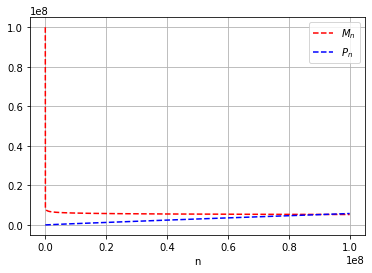

In [35]:
print(f"{N=:_}")

n = np.arange(1, N+1)
primes = compute_primes_less_than_n(N)
P_n = compute_P_n_array(N, primes)
h = compute_H_n_array(N)
M_n = N / h

MAX_N_PLOT = 100_000
RESCALE_FACTOR = N // MAX_N_PLOT if N > MAX_N_PLOT else 1

print(f"{RESCALE_FACTOR=:_}")
plt.plot(n[::RESCALE_FACTOR], M_n[::RESCALE_FACTOR], linestyle='--', color='red')
plt.plot(n[::RESCALE_FACTOR], P_n[::RESCALE_FACTOR], linestyle='--', color='blue')
plt.xlabel("n")
plt.grid()
plt.legend(["$M_n$", "$P_n$"])
plt.show()

N=100_000_000


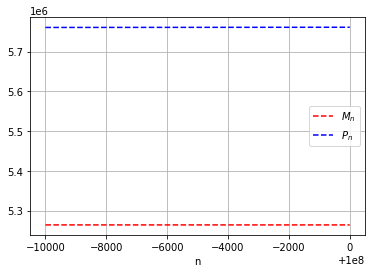

Mean relative error: $8.63423$%

In [36]:
print(f"{N=:_}")
### PLS EXECUTE THE CELL ABOVE ###

# Let's zoom the end of the graph

LAST_POINT = 10_000

n = np.arange(N-LAST_POINT+1, N+1)

plt.plot(n, M_n[-LAST_POINT:], linestyle='--', color='red')
plt.plot(n, P_n[-LAST_POINT:], linestyle='--', color='blue')
plt.xlabel("n")
plt.grid()
plt.legend(["$M_n$", "$P_n$"])
plt.show()

relative_error = np.abs(M_n[-LAST_POINT:] - P_n[-LAST_POINT:]) / P_n[-LAST_POINT:]
md_print(f"Mean relative error: ${np.mean(relative_error) * 100:.5f}$%")